## Milestone 1 - Data Selection & EDA

## Author: Gabriel Vance
## Class: DSC550 - Data Mining
## Professor: Dr. Brett Werner
## Date: August 2, 2025

# Purpose: For Milestone 1, I will explore some of the data structures as well as create data visualizations. My primary goal is to determine if geography bears any influence on chronic diseases in the USA. I will also explore whether or not demographics, such as race/sex, bear any role/responsibility for differences.

Do a graphical analysis creating a minimum of four graphs. Label your graphs appropriately and explain/analyze the information provided by each graph. Your analysis should begin to answer the question(s) you are addressing. Write a short overview/conclusion of the insights gained from your graphical analysis.

In [80]:
# Standard libraries
import numpy as np

# Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes

In [81]:
# Read in data
df = pd.read_csv('chronic_diseases.csv')
print(df.head())
print(df.shape)
print("Column Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

   YearStart  YearEnd LocationAbbr   LocationDesc     DataSource  \
0       2020     2020           US  United States          BRFSS   
1       2015     2019           AR       Arkansas  US Cancer DVT   
2       2015     2019           CA     California  US Cancer DVT   
3       2015     2019           CO       Colorado  US Cancer DVT   
4       2015     2019           GA        Georgia  US Cancer DVT   

           Topic                                           Question  Response  \
0  Health Status            Recent activity limitation among adults       NaN   
1         Cancer    Invasive cancer (all sites combined), incidence       NaN   
2         Cancer  Cervical cancer mortality among all females, u...       NaN   
3         Cancer    Invasive cancer (all sites combined), incidence       NaN   
4         Cancer  Prostate cancer mortality among all males, und...       NaN   

  DataValueUnit      DataValueType  ...  TopicID  QuestionID ResponseID  \
0        Number  Age-adjusted

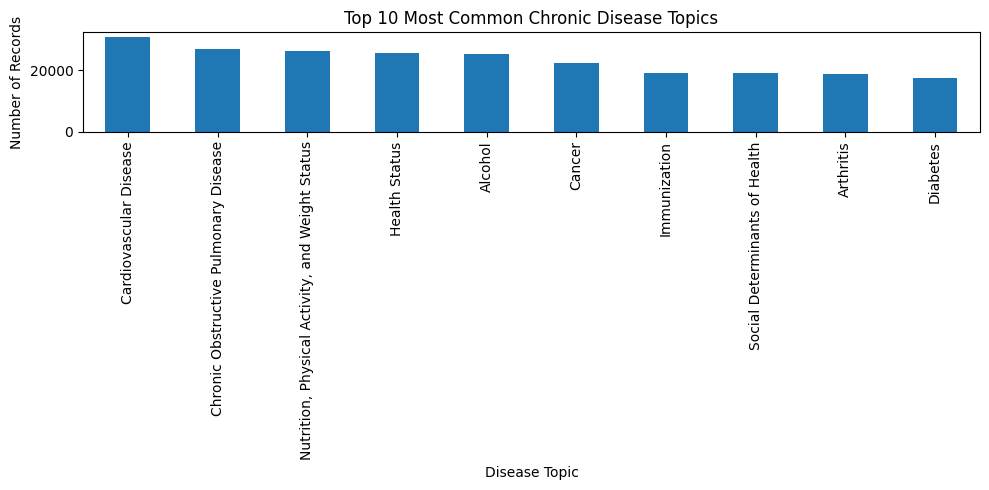

Graph 0 Analysis: This bar chart shows which chronic disease topics are most frequently recorded in the dataset. It highlights the focus areas in chronic disease surveillance.


In [82]:

# 1. Top 10 Most Common Chronic Disease Topics
top_topics = df['Topic'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_topics.plot(kind='bar')
plt.title('Top 10 Most Common Chronic Disease Topics')
plt.xlabel('Disease Topic')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()
print("Graph 0 Analysis: This bar chart shows which chronic disease topics are most frequently recorded in the dataset. It highlights the focus areas in chronic disease surveillance.")


In [83]:
usa_df = df[df['LocationDesc'] == 'United States']

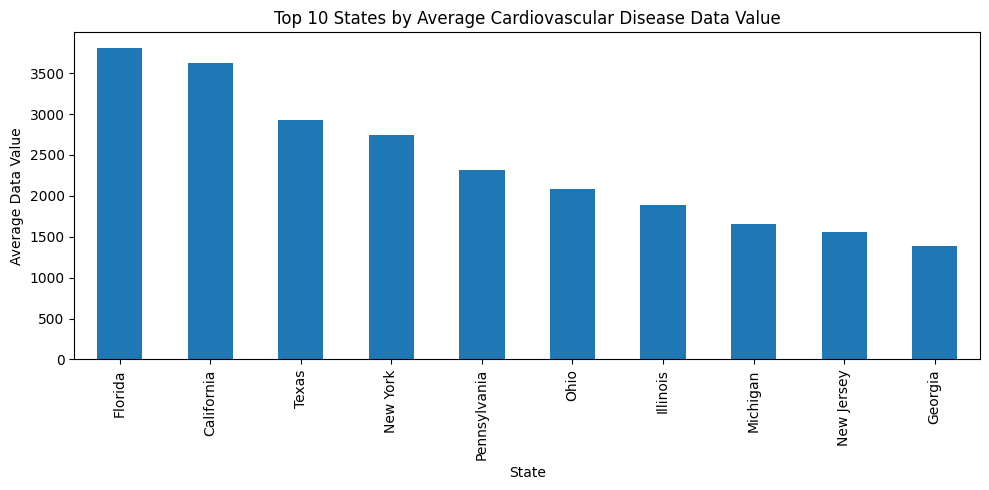

Graph 1 Analysis: This bar chart displays the top 10 states with the highest average data values for Cardiovascular Disease, revealing potential regional health disparities.


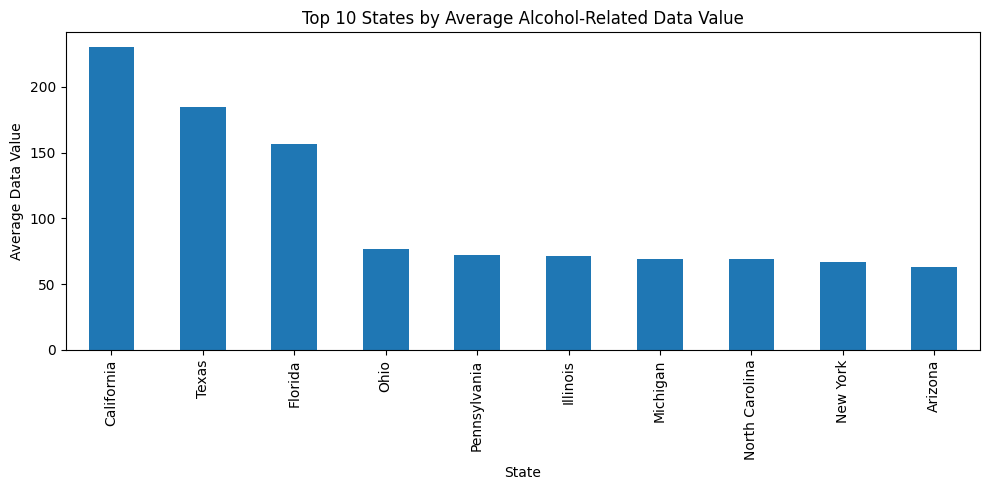

Graph 2 Analysis: This bar chart highlights the top 10 states with the highest average data values related to Alcohol consumption or impact.


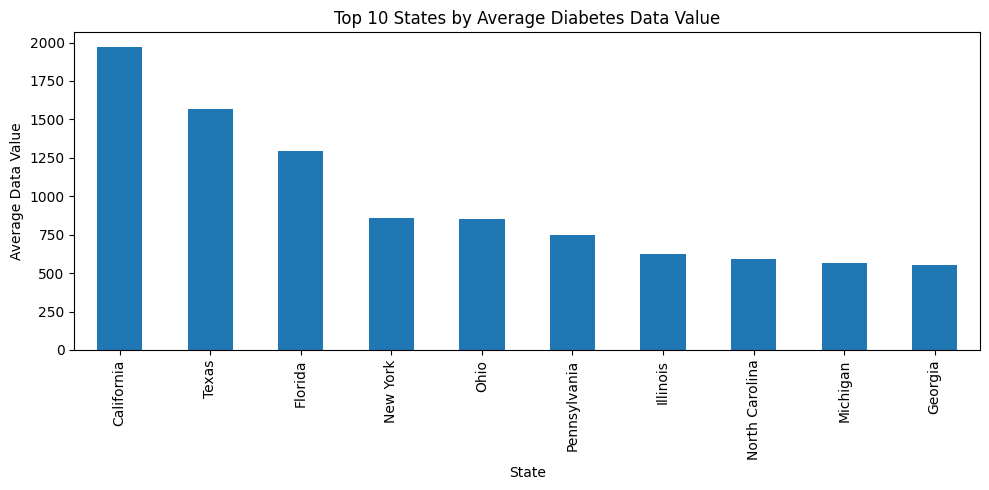

Graph 3 Analysis: This bar chart presents the top 10 states with the highest average data values for Diabetes, offering insights into diabetes prevalence by location.


In [84]:
# Separate the data: one for United States overall, one for individual states
state_data_df = df[df['LocationDesc'] != 'United States']

# 1. Top 10 States by Average Cardiovascular Disease Data Value
avg_cvd = state_data_df[state_data_df['Topic'] == 'Cardiovascular Disease'] \
    .groupby('LocationDesc')['DataValue'].mean().dropna().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
avg_cvd.plot(kind='bar')
plt.title('Top 10 States by Average Cardiovascular Disease Data Value')
plt.xlabel('State')
plt.ylabel('Average Data Value')
plt.tight_layout()
plt.show()
print("Graph 1 Analysis: This bar chart displays the top 10 states with the highest average data values for Cardiovascular Disease, revealing potential regional health disparities.")

# 2. Top 10 States by Average Alcohol-Related Data Value
avg_alcohol = state_data_df[state_data_df['Topic'] == 'Alcohol'] \
    .groupby('LocationDesc')['DataValue'].mean().dropna().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
avg_alcohol.plot(kind='bar')
plt.title('Top 10 States by Average Alcohol-Related Data Value')
plt.xlabel('State')
plt.ylabel('Average Data Value')
plt.tight_layout()
plt.show()
print("Graph 2 Analysis: This bar chart highlights the top 10 states with the highest average data values related to Alcohol consumption or impact.")

# 3. Top 10 States by Average Diabetes Data Value
avg_diabetes = state_data_df[state_data_df['Topic'] == 'Diabetes'] \
    .groupby('LocationDesc')['DataValue'].mean().dropna().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
avg_diabetes.plot(kind='bar')
plt.title('Top 10 States by Average Diabetes Data Value')
plt.xlabel('State')
plt.ylabel('Average Data Value')
plt.tight_layout()
plt.show()
print("Graph 3 Analysis: This bar chart presents the top 10 states with the highest average data values for Diabetes, offering insights into diabetes prevalence by location.")


In [85]:
high_school_drinking = usa_df[usa_df['Question'] == 'Alcohol use among high school students']
only_2021 = high_school_drinking[high_school_drinking['YearStart'] == 2021]
only_2019 = high_school_drinking[high_school_drinking['YearStart'] == 2019]

# print(only_2021.head())
print(only_2019.head())


       YearStart  YearEnd LocationAbbr   LocationDesc DataSource    Topic  \
331         2019     2019           US  United States      YRBSS  Alcohol   
84086       2019     2019           US  United States      YRBSS  Alcohol   
84262       2019     2019           US  United States      YRBSS  Alcohol   
87916       2019     2019           US  United States      YRBSS  Alcohol   
87920       2019     2019           US  United States      YRBSS  Alcohol   

                                     Question  Response DataValueUnit  \
331    Alcohol use among high school students       NaN             %   
84086  Alcohol use among high school students       NaN             %   
84262  Alcohol use among high school students       NaN             %   
87916  Alcohol use among high school students       NaN             %   
87920  Alcohol use among high school students       NaN             %   

          DataValueType  ...  TopicID  QuestionID ResponseID DataValueTypeID  \
331    Crude Preva

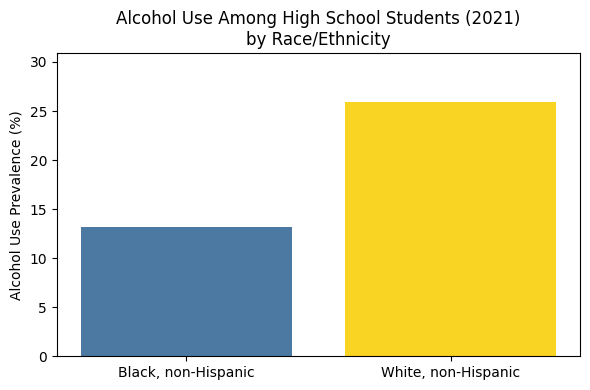

Graph 4 Analysis: This bar chart compares the prevalence of alcohol use among Black, non-Hispanic and White, non-Hispanic high school students in 2021.


In [86]:
# Plot the mean DataValue for Black, non-Hispanic and White, non-Hispanic high school drinking in 2021
black_value = only_2021[only_2021['Stratification1'] == 'Black, non-Hispanic']['DataValue'].mean()
white_value = only_2021[only_2021['Stratification1'] == 'White, non-Hispanic']['DataValue'].mean()

plt.figure(figsize=(6, 4))
plt.bar(['Black, non-Hispanic', 'White, non-Hispanic'], [black_value, white_value], color=['#4B79A1', '#F9D423'])
plt.ylabel('Alcohol Use Prevalence (%)')
plt.title('Alcohol Use Among High School Students (2021)\nby Race/Ethnicity')
plt.ylim(0, max(black_value, white_value) + 5)
plt.tight_layout()
plt.show()
print("Graph 4 Analysis: This bar chart compares the prevalence of alcohol use among Black, non-Hispanic and White, non-Hispanic high school students in 2021.")

In [87]:
# white_value_2021 = only_2021[only_2021['Stratification1'] == 'White, non-Hispanic']['DataValue']
white_value_2019 = only_2019[only_2019['Stratification1'] == 'White, non-Hispanic']['DataValue']

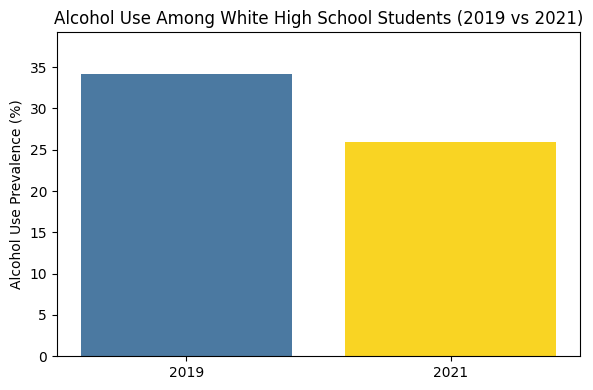

In [88]:
# Plot the mean DataValue for Black, non-Hispanic and White, non-Hispanic high school drinking in 2021
white_2019 = only_2019[only_2019['Stratification1'] == 'White, non-Hispanic']['DataValue'].mean()
white_value = only_2021[only_2021['Stratification1'] == 'White, non-Hispanic']['DataValue'].mean()

plt.figure(figsize=(6, 4))
plt.bar(['2019', '2021'], [white_2019, white_value], color=['#4B79A1', '#F9D423'])
plt.ylabel('Alcohol Use Prevalence (%)')
plt.title('Alcohol Use Among White High School Students (2019 vs 2021)')
plt.ylim(0, max(white_2019, white_value) + 5)
plt.tight_layout()
plt.show()

I analyzed several sections of the dataset, using bar charts for each. First, I examined the top 10 chronic illnesses to help guide my focus, avoiding topics with too few data points. I then compared diseases like diabetes and alcohol use across different states. To explore racial differences, I used a bar chart to compare alcohol consumption among Black and White high school students, revealing variations between racial groups. I also compared alcohol use among White students in 2019 versus 2021, showing how we can analyze changes within the same group over time.

There are multiple angles to explore, but I plan to focus on the racial and geographical factors influencing disease rates—particularly those related to alcohol use.

## Milestone 2 - Data Preparation

## Author: Gabriel Vance
## Class: DSC550 - Data Mining
## Professor: Dr. Brett Werner
## Date: July 20, 2025

# Purpose: We will refine the data to prepare for correlation modeling by focusing on related topics—mental health, alcohol use, and social determinants of health. Rows with null values (due to low response rates) will be removed, as they do not contribute meaningfully. This process will produce a clean dataset ready for analysis. Additionally, we will create various dataframes for each unique demographic.

In [89]:
# To find correlations, we'll focus on topics that are relevant to chronic diseases and health behaviors. For my purposes, I chose to focus on Alcohol, Mental Health, and Social Determinants of Health.
# These topics are often interrelated and can provide insights into how lifestyle factors influence chronic disease prevalence
selected_topics = ["Alcohol","Mental Health","Social Determinants of Health"]
df_selected = df[df['Topic'].isin(selected_topics)]
df_selected.head

<bound method NDFrame.head of         YearStart  YearEnd LocationAbbr   LocationDesc DataSource  \
70           2019     2019           AL        Alabama      BRFSS   
73           2019     2019           AK         Alaska      BRFSS   
79           2019     2019           AZ        Arizona      BRFSS   
84           2020     2020           WV  West Virginia      BRFSS   
87           2019     2019           AR       Arkansas      BRFSS   
...           ...      ...          ...            ...        ...   
309200       2022     2022           WV  West Virginia      BRFSS   
309204       2022     2022           UT           Utah      BRFSS   
309207       2022     2022           WV  West Virginia      BRFSS   
309213       2022     2022           VT        Vermont      BRFSS   
309214       2022     2022           WA     Washington      BRFSS   

                                Topic  \
70                      Mental Health   
73                            Alcohol   
79                

In [90]:
# Remove null values. These are often empty because the data has insufficent responses. The collectors tried to submit 1 response for each demographic, and in some cases demographics were not represented.
df_selected_clean = df_selected[df_selected['DataValue'].notnull()]
# Data will not be normalized as it is already normalized in the dataset.

In [91]:
# These columns are the ones we keep for further analysis. The other columns contained metadata about the data collection process or were duplicates of the same information.
relevant_columns = ['LocationDesc','Topic','Question','DataValueType','DataValue','StratificationCategory1','Stratification1']
df_selected_clean = df_selected_clean[relevant_columns]
# Display the cleaned DataFrame
print(df_selected_clean.head())

   LocationDesc          Topic                                Question  \
70      Alabama  Mental Health   Frequent mental distress among adults   
73       Alaska        Alcohol  Binge drinking prevalence among adults   
79      Arizona        Alcohol  Binge drinking prevalence among adults   
87     Arkansas  Mental Health                 Depression among adults   
88  Connecticut        Alcohol  Binge drinking prevalence among adults   

              DataValueType  DataValue StratificationCategory1 Stratification1  
70         Crude Prevalence       21.0                     Age       Age 18-44  
73         Crude Prevalence       11.1                     Sex          Female  
79         Crude Prevalence       20.9                     Age       Age 18-44  
87         Crude Prevalence       27.8                     Age       Age 18-44  
88  Age-adjusted Prevalence       20.8                     Sex            Male  


In [92]:
# These came from U.S. Census Bureau Regional Divisions

northeast = [
    'Connecticut', 'Maine', 'Massachusetts', 'New Hampshire', 'Rhode Island', 'Vermont',
    'New Jersey', 'New York', 'Pennsylvania'
]

midwest = [
    'Illinois', 'Indiana', 'Michigan', 'Ohio', 'Wisconsin',
    'Iowa', 'Kansas', 'Minnesota', 'Missouri', 'Nebraska', 'North Dakota', 'South Dakota'
]

south = [
    'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Maryland',
    'North Carolina', 'South Carolina', 'Virginia', 'West Virginia',
    'Alabama', 'Kentucky', 'Mississippi', 'Tennessee',
    'Arkansas', 'Louisiana', 'Oklahoma', 'Texas'
]

west = [
    'Arizona', 'Colorado', 'Idaho', 'Montana', 'Nevada', 'New Mexico', 'Utah', 'Wyoming',
    'Alaska', 'California', 'Hawaii', 'Oregon', 'Washington'
]


In [93]:
# We can create Regions to group data.

def get_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Other'

# Apply the function to create a new 'Region' column
df_selected_clean['Region'] = df_selected_clean['LocationDesc'].apply(get_region)
print(df_selected_clean[['LocationDesc', 'Region']].head())

   LocationDesc     Region
70      Alabama      South
73       Alaska       West
79      Arizona       West
87     Arkansas      South
88  Connecticut  Northeast


### We can't train on demographics with low response rates. We'll have to pick groups which had high response rates.

In [94]:
# These are the unique values for each demographic
print(df_selected_clean['Stratification1'].unique())

['Age 18-44' 'Female' 'Male' 'Overall' 'Multiracial, non-Hispanic'
 'Age 45-64' 'Age >=65' 'White, non-Hispanic' 'Hispanic' 'Grade 10'
 'Grade 12' 'Grade 11' 'Black, non-Hispanic' 'Asian, non-Hispanic'
 'Age 0-44' 'Grade 9' 'American Indian or Alaska Native, non-Hispanic'
 'Hawaiian or Pacific Islander, non-Hispanic']


In [95]:
# Count the number of rows for each unique 'Stratification1' value and sort by count descending
strat_counts = df_selected_clean['Stratification1'].value_counts().sort_values(ascending=False)

# Print the results
for strat, count in strat_counts.items():
    print(f"{strat}: {count}")

Overall: 5288
White, non-Hispanic: 4826
Male: 4595
Female: 4562
Hispanic: 3854
Black, non-Hispanic: 3278
Age 45-64: 2523
Multiracial, non-Hispanic: 2465
Age 18-44: 2228
Age >=65: 2130
Asian, non-Hispanic: 1646
American Indian or Alaska Native, non-Hispanic: 1595
Age 0-44: 284
Hawaiian or Pacific Islander, non-Hispanic: 283
Grade 11: 220
Grade 9: 220
Grade 12: 220
Grade 10: 220


### We're going to create dfs for each stratification. There's a possibility we can consider all of the data together, but for now we need to predict based on a single stratification.

In [96]:
# Separate each df into individual DataFrames based on 'Stratification1' values

grade_9 = df_selected_clean[df_selected_clean['Stratification1'] == 'Grade 9']
grade_10 = df_selected_clean[df_selected_clean['Stratification1'] == 'Grade 10']
grade_11 = df_selected_clean[df_selected_clean['Stratification1'] == 'Grade 11']
grade_12 = df_selected_clean[df_selected_clean['Stratification1'] == 'Grade 12']
female = df_selected_clean[df_selected_clean['Stratification1'] == 'Female']
male = df_selected_clean[df_selected_clean['Stratification1'] == 'Male']
overall = df_selected_clean[df_selected_clean['Stratification1'] == 'Overall']
asian_non_hispanic = df_selected_clean[df_selected_clean['Stratification1'] == 'Asian, non-Hispanic']
black_non_hispanic = df_selected_clean[df_selected_clean['Stratification1'] == 'Black, non-Hispanic']
hispanic = df_selected_clean[df_selected_clean['Stratification1'] == 'Hispanic']
multiracial_non_hispanic = df_selected_clean[df_selected_clean['Stratification1'] == 'Multiracial, non-Hispanic']
white_non_hispanic = df_selected_clean[df_selected_clean['Stratification1'] == 'White, non-Hispanic']
american_indian_alaska_native_non_hispanic = df_selected_clean[df_selected_clean['Stratification1'] == 'American Indian or Alaska Native, non-Hispanic']
hawaiian_pacific_islander_non_hispanic = df_selected_clean[df_selected_clean['Stratification1'] == 'Hawaiian or Pacific Islander, non-Hispanic']
age_18_44 = df_selected_clean[df_selected_clean['Stratification1'] == 'Age 18-44']
age_45_64 = df_selected_clean[df_selected_clean['Stratification1'] == 'Age 45-64']
age_65_plus = df_selected_clean[df_selected_clean['Stratification1'] == 'Age >=65']

# Note, while we make dfs for each strat, we're only going to use the ones with the most data. 

In [97]:
# Print the current shape now that we've cleaned the data
print(white_non_hispanic.shape)
print("Column Names:", white_non_hispanic.columns.tolist())
print("\nData Types:\n", white_non_hispanic.dtypes)

(4826, 8)
Column Names: ['LocationDesc', 'Topic', 'Question', 'DataValueType', 'DataValue', 'StratificationCategory1', 'Stratification1', 'Region']

Data Types:
 LocationDesc                object
Topic                       object
Question                    object
DataValueType               object
DataValue                  float64
StratificationCategory1     object
Stratification1             object
Region                      object
dtype: object


Our data is now prepared for training and modeling. In Milestone 3, we will apply clustering to group data by region, forming one cluster per region. A randomly selected state from each region will be excluded during clustering and used to assess whether the model correctly predicts its regional assignment. This analysis will focus on three demographic groups: White, non-Hispanic; Female; and Age 45–64, using the metric “Binge drinking frequency among adults who binge drink.” The objective is to evaluate the influence of regional differences on clustering outcomes.

Next, we will perform cross-cluster prediction using the variable “Living below 150% of the poverty threshold among all people.” We will create clusters based on various demographics and attempt to predict cluster membership using a selected demographic feature.

Finally, we will use data for Black, non-Hispanic; Male; and Age 18–44 to perform linear regression. We’ll identify highly correlated metrics—such as alcoholism and depression—and evaluate the ability to predict one based on the other. This analysis will be conducted across demographics, independent of geographic location.

## Milestone 3 - Model Building and Evaluation

## Author: Gabriel Vance
## Class: DSC550 - Data Mining
## Professor: Dr. Brett Werner
## Date: August 6, 2025

# Purpose: We will use clustering, classification, and regression to analyze the data. The goal is to explore how demographics and geography influence chronic diseases, particularly focusing on alcohol use and mental health.

### First, we will use clustering to group data by region, forming one cluster per region. A randomly selected state from each region will be excluded during clustering and used to assess whether the model correctly predicts its regional assignment. 

In [98]:
region_training_dfs = {
    'white_non_hispanic': white_non_hispanic,
    'female':female,
    'age_45_64': age_45_64,
}
topic = 'Binge drinking frequency among adults who binge drink'

In [99]:
# This cell performs clustering based on K-Means. While it underperformed with only 25% accuracy, it provides a baseline for comparison.
regions = ['Northeast', 'Midwest', 'South', 'West']

def get_training_df(demographic_df, topic):
    df = demographic_df[demographic_df['Question'] == topic].copy()
    df = df[df['Region'].isin(regions)]
    
    test_rows = []
    train_rows = []

    for region in regions:
        region_df = df[df['Region'] == region]
        test_rows.append(region_df.iloc[0])
        train_rows.append(region_df.iloc[1:])

    train_df = pd.concat(train_rows)
    test_df = pd.DataFrame(test_rows)

    print("Test rows removed:")
    print(test_df[['Region', 'LocationDesc', 'DataValue']])
    
    return train_df, test_df

def cluster_and_evaluate_kmeans(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    # Use only 'DataValue' as input to KMeans
    X_train = train_df[['DataValue']].values
    X_test = test_df[['DataValue']].values
    
    # Fit KMeans on training data
    kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
    clusters_train = kmeans.fit_predict(X_train)
    train_df['Cluster'] = clusters_train

    # Cluster-to-Region mapping (most common region per cluster)
    cluster_region_table = pd.crosstab(train_df['Cluster'], train_df['Region'])
    cluster_to_region = cluster_region_table.idxmax(axis=1).to_dict()
    
    # Purity calculation
    purity = np.sum(np.amax(cluster_region_table.values, axis=1)) / np.sum(cluster_region_table.values)
    print("\n--- Cluster vs Region Table ---")
    print(cluster_region_table)
    print(f"Silo Score (Purity): {purity:.2f}")
    
    # Predict clusters for test set
    clusters_test = kmeans.predict(X_test)
    test_df['PredictedCluster'] = clusters_test
    test_df['PredictedRegion'] = test_df['PredictedCluster'].map(cluster_to_region)

    # Accuracy
    correct = (test_df['Region'] == test_df['PredictedRegion']).sum()
    total = len(test_df)
    accuracy = correct / total
    
    print("\n--- Test Predictions ---")
    print(test_df[['LocationDesc', 'Region', 'PredictedRegion']])
    print(f"Accuracy: {correct}/{total} ({accuracy:.2f})")

# Example loop to run the clustering
for demographic, demographic_df in region_training_dfs.items():
    print(f"\n\n### {demographic} ###")
    train_df, test_df = get_training_df(demographic_df, topic)
    cluster_and_evaluate_kmeans(train_df, test_df)



### white_non_hispanic ###
Test rows removed:
          Region LocationDesc  DataValue
345    Northeast      Vermont        4.7
497      Midwest     Missouri        4.8
16164      South     Arkansas        5.8
16005       West       Alaska        1.7

--- Cluster vs Region Table ---
Region   Midwest  Northeast  South  West
Cluster                                 
0             48         35     67    51
1             27         12     40    25
2             20         22     19    24
3              0          0      7     2
Silo Score (Purity): 0.35

--- Test Predictions ---
      LocationDesc     Region PredictedRegion
345        Vermont  Northeast           South
497       Missouri    Midwest           South
16164     Arkansas      South           South
16005       Alaska       West           South
Accuracy: 1/4 (0.25)


### female ###
Test rows removed:
          Region  LocationDesc  DataValue
1037   Northeast  Pennsylvania        1.5
811      Midwest  South Dakota        3.8
320

In [100]:
# For each region, we will use unsupervised clustering to assess how well a model can predict a region based on demographicss
regions = ['Northeast', 'Midwest', 'South', 'West']

def get_training_df(demographic_df, topic):
    # Step 1: Filter by topic and valid regions
    df = demographic_df[demographic_df['Question'] == topic].copy()
    df = df[df['Region'].isin(regions)]
    
    # Step 2: Remove 1 row per region for testing
    test_rows = []
    train_rows = []

    for region in regions:
        region_df = df[df['Region'] == region]

        test_rows.append(region_df.iloc[0])
        train_rows.append(region_df.iloc[1:])

    train_df = pd.concat(train_rows)
    test_df = pd.DataFrame(test_rows)

    print("Test rows removed:")
    print(test_df[['Region', 'LocationDesc', 'DataValue']])
    
    return train_df, test_df


def cluster_and_evaluate_kmodes(train_df, test_df):
    # Convert 'DataValue' into categorical bins (e.g., quartiles) for kmodes
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    # Bin 'DataValue' into 4 categories 
    train_df['DataValue_bin'] = pd.qcut(train_df['DataValue'], q=4, labels=False)
    test_df['DataValue_bin'] = pd.qcut(test_df['DataValue'], q=4, labels=False)
    
    # Use only categorical columns for clustering
    X_train = train_df[['Region', 'DataValue_bin']].astype(str)
    X_test = test_df[['Region', 'DataValue_bin']].astype(str)
    
    # Initialize K-Modes (categorical clusters)
    km = KModes(n_clusters=4, init='Huang', n_init=5, random_state=42)
    clusters_train = km.fit_predict(X_train)
    train_df['Cluster'] = clusters_train
    
    # Cluster vs Region table (purity)
    cluster_region_table = pd.crosstab(train_df['Cluster'], train_df['Region'])
    purity = np.sum(np.amax(cluster_region_table.values, axis=1)) / np.sum(cluster_region_table.values)
    
    print("\n--- Cluster vs Region Table ---")
    print(cluster_region_table)
    print(f"Silo Score (Purity): {purity:.2f}")
    
    # Map cluster to most frequent region in training data
    cluster_to_region = train_df.groupby('Cluster')['Region'] \
                                .agg(lambda x: x.value_counts().idxmax()) \
                                .to_dict()
    
    # Predict clusters for test data
    clusters_test = km.predict(X_test)
    test_df['PredictedCluster'] = clusters_test
    test_df['PredictedRegion'] = test_df['PredictedCluster'].map(cluster_to_region)
    
    # Accuracy on test data
    correct = (test_df['Region'] == test_df['PredictedRegion']).sum()
    total = len(test_df)
    accuracy = correct / total
    
    print("\n--- Test Predictions ---")
    print(test_df[['LocationDesc', 'Region', 'PredictedRegion']])
    print(f"Accuracy: {correct}/{total} ({accuracy:.2f})")


for demographic, demographic_df in region_training_dfs.items():
    train_df, test_df = get_training_df(demographic_df, topic)
    print(demographic)
    cluster_and_evaluate_kmodes(train_df, test_df)

Test rows removed:
          Region LocationDesc  DataValue
345    Northeast      Vermont        4.7
497      Midwest     Missouri        4.8
16164      South     Arkansas        5.8
16005       West       Alaska        1.7
white_non_hispanic

--- Cluster vs Region Table ---
Region   Midwest  Northeast  South  West
Cluster                                 
0             20         15    133    21
1             75         25      0     0
2              0         29      0    51
3              0          0      0    30
Silo Score (Purity): 0.72

--- Test Predictions ---
      LocationDesc     Region PredictedRegion
345        Vermont  Northeast           South
497       Missouri    Midwest         Midwest
16164     Arkansas      South           South
16005       Alaska       West            West
Accuracy: 3/4 (0.75)
Test rows removed:
          Region  LocationDesc  DataValue
1037   Northeast  Pennsylvania        1.5
811      Midwest  South Dakota        3.8
320        South         Texas

The K-Mode clustering allowed us to cluster closer to the geographical region. By comparing the purity score to the accuracy score, we can see that the model generally excells in predicting clusters when the purity is high. For example, the white_non_hispanic demographic showed strong influence with the regions. The silo purity was 72% and the accuracy was 75%. When controlling for gender and age, the regions were less consistent, with purity scores in the 60%. 

In [101]:
# Racial Demographic DataFrames
racial_demographic_df =  [asian_non_hispanic, black_non_hispanic, hispanic, multiracial_non_hispanic, white_non_hispanic, american_indian_alaska_native_non_hispanic, hawaiian_pacific_islander_non_hispanic]
# Concat dfs into single df
racial_demographic_df = pd.concat(racial_demographic_df, ignore_index=True)
racial_demographic_df.head()

,LocationDesc,Topic,Question,DataValueType,DataValue,StratificationCategory1,Stratification1,Region
0,Hawaii,Mental Health,Frequent mental distress among adults,Crude Prevalence,7.7,Race/Ethnicity,"Asian, non-Hispanic",West
1,Maryland,Mental Health,Frequent mental distress among adults,Age-adjusted Prevalence,10.9,Race/Ethnicity,"Asian, non-Hispanic",South
2,Iowa,Social Determinants of Health,Lack of social and emotional support needed am...,Age-adjusted Prevalence,17.0,Race/Ethnicity,"Asian, non-Hispanic",Midwest
3,California,Alcohol,Chronic liver disease mortality among all peop...,Age-adjusted Rate,3.4,Race/Ethnicity,"Asian, non-Hispanic",West
4,Arkansas,Alcohol,Alcohol use among high school students,Crude Prevalence,25.3,Race/Ethnicity,"Asian, non-Hispanic",South


In [102]:
# Filter for our question
racial_demographic_df = racial_demographic_df[racial_demographic_df['Question'] == "Average mentally unhealthy days among adults"]
racial_demographic_df.head()

,LocationDesc,Topic,Question,DataValueType,DataValue,StratificationCategory1,Stratification1,Region
62,Hawaii,Mental Health,Average mentally unhealthy days among adults,Age-adjusted Mean,3.2,Race/Ethnicity,"Asian, non-Hispanic",West
64,California,Mental Health,Average mentally unhealthy days among adults,Crude Mean,4.6,Race/Ethnicity,"Asian, non-Hispanic",West
98,California,Mental Health,Average mentally unhealthy days among adults,Age-adjusted Mean,4.4,Race/Ethnicity,"Asian, non-Hispanic",West
141,Hawaii,Mental Health,Average mentally unhealthy days among adults,Crude Mean,3.1,Race/Ethnicity,"Asian, non-Hispanic",West
219,Maryland,Mental Health,Average mentally unhealthy days among adults,Crude Mean,5.4,Race/Ethnicity,"Asian, non-Hispanic",South


In [103]:
# This time we'll try a classification problem
# Drop rows with missing DataValue or Stratification1
df = racial_demographic_df.dropna(subset=['DataValue', 'Stratification1'])

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(df['Stratification1'])
X = df[['DataValue']]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict and print accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification accuracy: {accuracy:.2f}")

Classification accuracy: 0.41


This was less accurate. The model only predicted with 41% accuracy. This shows that racial demographics are not as strongly correlated as other demographics. 

In [104]:
# For linear regression, we'll create more features using a pivot table
age_45_64_pivot = age_45_64.pivot_table(
    index=['LocationDesc', 'Region'],
    columns='Question',
    values='DataValue'
).reset_index()

print(age_45_64_pivot.head())

Question LocationDesc Region  Average mentally unhealthy days among adults  \
0             Alabama  South                                         2.975   
1              Alaska   West                                         3.575   
2             Arizona   West                                         3.425   
3            Arkansas  South                                         3.150   
4          California   West                                         3.850   

Question  Binge drinking frequency among adults who binge drink  \
0                                                  3.512500       
1                                                  3.575000       
2                                                  3.087500       
3                                                  4.500000       
4                                                  3.228571       

Question  Binge drinking intensity among adults who binge drink  \
0                                                    6.1375  

In [105]:
# Print the column names. These are going to be used for linear regression.
print(age_45_64_pivot.columns.tolist())

['LocationDesc', 'Region', 'Average mentally unhealthy days among adults', 'Binge drinking frequency among adults who binge drink', 'Binge drinking intensity among adults who binge drink', 'Binge drinking prevalence among adults', 'Chronic liver disease mortality among all people, underlying cause', 'Depression among adults', 'Frequent mental distress among adults', 'Lack of health insurance among adults aged 18-64 years', 'Lack of reliable transportation in the past 12 months among adults', 'Lack of social and emotional support needed among adults', 'Routine checkup within the past year among adults', 'Unable to pay mortgage, rent, or utility bills in the past 12 months among adults']


In [106]:
# This will try to predict numerical values with other columns generated from the pivot table
target = 'Routine checkup within the past year among adults'

# List of questions to use
question_cols = [
    'Average mentally unhealthy days among adults',
    'Binge drinking frequency among adults who binge drink',
    'Binge drinking intensity among adults who binge drink',
    'Binge drinking prevalence among adults',
    'Chronic liver disease mortality among all people, underlying cause',
    'Depression among adults',
    'Frequent mental distress among adults',
    'Lack of health insurance among adults aged 18-64 years',
    'Lack of reliable transportation in the past 12 months among adults',
    'Lack of social and emotional support needed among adults',
    'Routine checkup within the past year among adults', 
    'Unable to pay mortgage, rent, or utility bills in the past 12 months among adults'
]

# Drop rows with missing target
pivot_df = age_45_64_pivot.dropna(subset=[target])

# Select features and target
features = [q for q in question_cols if q != target] # This allowed me to switch the target question easily
X = pivot_df[features]
y = pivot_df[target]

# Drop rows with missing values in features
X = X.dropna()
y = y.loc[X.index]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Print accuracy (R^2 score)
print(f"Linear Regression R^2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

# Print top contributing features
coef_abs = np.abs(lr.coef_)
top_features = np.array(X.columns)[np.argsort(coef_abs)[::-1][:3]]
print("\nTop 3 contributing features:")
for feat in top_features:
    print(feat)

Linear Regression R^2 Score: 0.81
Mean Squared Error: 2.73

Top 3 contributing features:
Average mentally unhealthy days among adults
Binge drinking intensity among adults who binge drink
Binge drinking frequency among adults who binge drink


I had to try several different Questions before I found the best one to predict. The linear regression model was able to predict 'Routine checkup within the past year among adults' variance with 81 accuracy, a pretty good estimate. I was also able to identify the top 3 contributing features: Average mentally unhealthy days among adults, Binge drinking intensity among adults who binge drink, and Binge drinking frequency among adults who binge drink. This method showed the highest overall accuracy.